# ZeroLifestyle Product Catalog — Full Analysis Pipeline

**Flow:** Data Collection → Loading → Initial Inspection → Cleaning → EDA → Problem Statement → Feature Engineering → Statistical Modeling → Conclusion

## 1️⃣ Data Collection (Web Scraping Pipeline)
Ye pipeline ZeroLifestyle store se product data scrape karke `zerolifestyle_complete_master_database.csv` banata hai. **Ye already execute ho chuki hai** — sirf reference/documentation ke liye rakha gaya hai, dobara run karne ki zaroorat nahi (agar CSV pehle se maujood hai).

In [1]:
import csv
import time
import requests
from bs4 import BeautifulSoup
import re

# --- HELPER: NETWORK REQUEST WITH LIMITED RETRIES ---
def robust_network_request(url, max_retries=3):
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
    }
    wait_time = 5
    for attempt in range(1, max_retries + 1):
        try:
            response = requests.get(url, headers=headers, timeout=60)
            response.raise_for_status()
            if attempt > 1:
                print(f"✅ Succeeded on attempt {attempt}/{max_retries} for {url}")
            return response
        except requests.RequestException as e:
            print(f"⚠️ Attempt {attempt}/{max_retries} failed for {url}: {e}")
            if attempt == max_retries:
                print(f"❌ Giving up on {url} after {max_retries} attempts.")
                return None
            time.sleep(wait_time)
            wait_time = min(wait_time * 2, 30)
    return None

# --- STEP 1: HARVEST ALL PRODUCTS FROM products.json ---
def harvest_all_products(base_url):
    print("Connecting to store product API...")
    all_products = []
    page = 1
    limit = 50

    while True:
        api_url = f"{base_url.rstrip('/')}/products.json?limit={limit}&page={page}"
        print(f"Requesting page {page}...")
        response = robust_network_request(api_url)
        if response is None:
            print(f"Skipping page {page} after failed retries.")
            break

        data = response.json()
        products_chunk = data.get("products", [])
        if not products_chunk:
            print("No more products found. Stopping.")
            break

        all_products.extend(products_chunk)
        print(f"  Got {len(products_chunk)} products (total: {len(all_products)})")
        page += 1
        time.sleep(1)

    print(f"Total products harvested: {len(all_products)}")
    return all_products


# --- STEP 2: FETCH REAL RATING/REVIEWS FROM THE PRODUCT PAGE ---
import re

def fetch_product_page_extras(product_url):
    """Scrapes the actual product page for the rating/review count that
    belongs specifically to THIS product (scoped inside <product-meta>),
    not a random badge from a sitewide carousel/widget."""
    response = robust_network_request(product_url)
    if response is None:
        return {"rating": None, "review_count": None}

    soup = BeautifulSoup(response.text, "html.parser")

    # Scope search to the product-meta block so we don't grab a badge
    # belonging to a "Best Sellers" / "Recently Viewed" widget elsewhere on the page
    meta_block = soup.select_one("product-meta")

    rating = None
    review_count = None

    if meta_block:
        stars_el = meta_block.select_one(".rating__stars[aria-label]")
        if stars_el:
            match = re.search(r"([\d.]+)\s*out of", stars_el.get("aria-label", ""))
            if match:
                rating = match.group(1)

        caption_el = meta_block.select_one(".rating__caption")
        if caption_el:
            match = re.search(r"(\d+)", caption_el.get_text())
            if match:
                review_count = match.group(1)

    return {"rating": rating, "review_count": review_count}


# --- STEP 3: PROCESS RAW PRODUCTS INTO A CLEAN DATASET ---
def process_products(raw_products, base_url):
    cleaned = []
    total = len(raw_products)

    for count, prod in enumerate(raw_products, 1):
        product_id = prod.get("id")
        product_name = " ".join(prod.get("title", "").split()).strip() or None
        handle = prod.get("handle", "")
        product_url = f"{base_url.rstrip('/')}/products/{handle}" if handle else None
        product_type = " ".join(prod.get("product_type", "").split()).strip() or None
        tags = prod.get("tags", [])
        tags_string = ", ".join(tags) if tags else None

        # Pricing / stock from variants
        variants = prod.get("variants", [])
        sale_price = None
        original_price = None
        discount_percentage = None
        stock_status = None

        if variants:
            s_price = variants[0].get("price")
            c_price = variants[0].get("compare_at_price")

            if s_price:
                sale_price = f"Rs.{float(s_price):,.0f}"

            if c_price:
                original_price = f"Rs.{float(c_price):,.0f}"
                try:
                    disc = ((float(c_price) - float(s_price)) / float(c_price)) * 100
                    discount_percentage = f"{int(round(disc))}% OFF"
                except (ValueError, ZeroDivisionError):
                    discount_percentage = None
            else:
                # No compare_at_price means no discount data exists
                original_price = sale_price
                discount_percentage = "0% OFF"

            is_available = any(v.get("available", False) for v in variants)
            stock_status = "In Stock" if is_available else "Out of Stock"

        # Colors / variant options
        colors_list = []
        for opt in prod.get("options", []):
            if opt.get("name", "").lower() in ("color", "colour"):
                colors_list = opt.get("values", [])
                break
        colors_string = ", ".join(colors_list) if colors_list else None

        # Fetch real rating + review count from the product page itself
        extras = {"rating": None, "review_count": None}
        if product_url:
            extras = fetch_product_page_extras(product_url)
            time.sleep(0.5)  # be polite to the server

        record = {
            "Product_ID": product_id,
            "Product_Name": product_name,
            "Category_Type": product_type,
            "Sale_Price": sale_price,
            "Original_Price": original_price,
            "Discount_Percentage": discount_percentage,
            "Rating": extras["rating"],
            "Review_Count": extras["review_count"],
            "Stock_Status": stock_status,
            "Available_Colors": colors_string,
            "Tags": tags_string,
            "Source_URL": product_url,
        }

        cleaned.append(record)
        print(f"[{count}/{total}] {product_name} | Rating: {record['Rating']} | Price: {sale_price}")

    return cleaned


# --- STEP 4: SAVE TO CSV ---
def save_to_csv(records, filename="zerolifestyle_complete_master_database.csv"):
    if not records:
        print("No records to save.")
        return

    fields = list(records[0].keys())
    with open(filename, mode="w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fields)
        writer.writeheader()
        writer.writerows(records)

    print(f"Saved {len(records)} records to '{filename}'")


# --- MAIN ---
if __name__ == "__main__":
    domain_target = "https://zerolifestyle.co"

    raw_products = harvest_all_products(domain_target)
    if raw_products:
        final_dataset = process_products(raw_products, domain_target)
        save_to_csv(final_dataset)

Connecting to store product API...
Requesting page 1...
  Got 50 products (total: 50)
Requesting page 2...
  Got 45 products (total: 95)
Requesting page 3...
No more products found. Stopping.
Total products harvested: 95
[1/95] Lumin L-300 Power Bank | Rating: 0 | Price: Rs.24,999
[2/95] Core X 10000 Power Bank | Rating: 5.0 | Price: Rs.9,499
[3/95] Glide Zbuds | Rating: 0 | Price: Rs.8,499
[4/95] Pulse Pro 200 Power Bank | Rating: 0 | Price: Rs.12,999
[5/95] Regal AI Pro Smartwatch | Rating: 5.0 | Price: Rs.29,999
[6/95] Arcade Nitro Zbuds | Rating: 5.0 | Price: Rs.6,499
[7/95] Nexus Pro Zbuds | Rating: 4.79 | Price: Rs.7,999
[8/95] Pakistan Edition Z BUDS | Rating: 4.5 | Price: Rs.9,999
[9/95] Voltix V-200 Power Bank | Rating: 4.62 | Price: Rs.9,499
[10/95] Lumin L-200 Power Bank | Rating: 4.5 | Price: Rs.8,999
[11/95] Lumin L-100 Power Bank | Rating: 4.86 | Price: Rs.5,999
[12/95] Voltix V-100 Power Bank | Rating: 4.77 | Price: Rs.5,999
[13/95] Gravity Pro Earbuds | Rating: 4.59 | P

## 2️⃣ Load & Verify Data

In [2]:
import pandas as pd

try:
    # 1. Pipeline ke zariye banni hui master CSV ko Pandas mein load karein
    df = pd.read_csv("zerolifestyle_complete_master_database.csv")
    
    print("=========================================================================")
    print("🎉 PROJECT COMPLETION STATUS: METRICS VERIFIED SUCCESSFULLY!")
    print("=========================================================================\n")
    
    # 2. Check karein ke total kitne rows aur columns extract hue hain
    print(f"📈 Total Extracted Rows (Products): {df.shape[0]}")
    print(f"🗂️ Total Core Parameters (Columns):  {df.shape[1]}")
    print(f"📋 Table Column Headers: {list(df.columns)}\n")
    
    # 3. Shuru ke 3 items ka bilkul saaf layout table view dekhna
    print("🎨 --- PHYSICAL INTERFACE DATA SAMPLES (FIRST 3 ROWS) ---")
    display(df.head())
    
    # 4. Check karna ke data clean hai ya nahi (Null test)
    print("\n🧹 --- ARTIFACT CLEANUP & DATA INTEGRITY TEST ---")
    missing_data = df.isnull().sum()
    if missing_data.sum() == 0:
        print("✅ Success: No whitespace artifacts or missing nodes found. Data is 100% clean!")
    else:
        print("⚠️ Current Blank/Null counters per column:")
        print(missing_data)
        
except FileNotFoundError:
    print("❌ Critical Error: Master CSV file nahi mili! Pehle pipeline wala cell poora run hone dein.")
except Exception as e:
    print(f"❌ Verification fail ho gayi: {e}")


🎉 PROJECT COMPLETION STATUS: METRICS VERIFIED SUCCESSFULLY!

📈 Total Extracted Rows (Products): 95
🗂️ Total Core Parameters (Columns):  12
📋 Table Column Headers: ['Product_ID', 'Product_Name', 'Category_Type', 'Sale_Price', 'Original_Price', 'Discount_Percentage', 'Rating', 'Review_Count', 'Stock_Status', 'Available_Colors', 'Tags', 'Source_URL']

🎨 --- PHYSICAL INTERFACE DATA SAMPLES (FIRST 3 ROWS) ---


,Product_ID,Product_Name,Category_Type,Sale_Price,Original_Price,Discount_Percentage,Rating,Review_Count,Stock_Status,Available_Colors,Tags,Source_URL
0,10602954522902,Lumin L-300 Power Bank,Powerbank,"Rs.24,999","Rs.45,999",46% OFF,0.0,NaN,In Stock,"Orange, Black","powerbank, pre-order",https://zerolifestyle.co/products/lumin-l-300-...
1,10674292195606,Core X 10000 Power Bank,Powerbank,"Rs.9,499","Rs.23,999",60% OFF,5.0,1.0,In Stock,"Gray, Silver","powerbank, pre-order",https://zerolifestyle.co/products/core-x-power...
2,10692509368598,Glide Zbuds,Earbuds,"Rs.8,499","Rs.15,999",47% OFF,0.0,NaN,In Stock,"Black, Blue, Green","earbuds, pre-order",https://zerolifestyle.co/products/glide-zbuds
3,10674295570710,Pulse Pro 200 Power Bank,Powerbank,"Rs.12,999","Rs.24,999",48% OFF,0.0,NaN,In Stock,Black,"powerbank, pre-order",https://zerolifestyle.co/products/pulse-pro-po...
4,10552248467734,Regal AI Pro Smartwatch,Smart Watch,"Rs.29,999","Rs.39,999",25% OFF,5.0,2.0,In Stock,"Black Gold, Brown Gold, Silver Black, Green Go...","pre-order, smartwatch",https://zerolifestyle.co/products/regal-ai-pro...



🧹 --- ARTIFACT CLEANUP & DATA INTEGRITY TEST ---
⚠️ Current Blank/Null counters per column:
Product_ID             0
Product_Name           0
Category_Type          1
Sale_Price             0
Original_Price         0
Discount_Percentage    0
Rating                 0
Review_Count           3
Stock_Status           0
Available_Colors       0
Tags                   3
Source_URL             0
dtype: int64


## 3️⃣ Initial Inspection
Modeling shuru karne se pehle dataset ka structure samajhna — columns, data types, shape, duplicates, aur har column ki unique values.

In [3]:
df.columns

Index(['Product_ID', 'Product_Name', 'Category_Type', 'Sale_Price',
       'Original_Price', 'Discount_Percentage', 'Rating', 'Review_Count',
       'Stock_Status', 'Available_Colors', 'Tags', 'Source_URL'],
      dtype='str')

In [4]:
df.dtypes

Product_ID               int64
Product_Name               str
Category_Type              str
Sale_Price                 str
Original_Price             str
Discount_Percentage        str
Rating                 float64
Review_Count           float64
Stock_Status               str
Available_Colors           str
Tags                       str
Source_URL                 str
dtype: object

In [5]:
df.shape

(95, 12)

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
for col in df.columns:
    col_dtype = df[col].dtype
    unique_count = df[col].nunique()
    unique_list = df[col].unique().tolist()

    print(f"COLUMN NAME: '{col}' | Data Type: {col_dtype}")
    print(unique_list)
    print(f"Total Unique Values Count: {unique_count}")

COLUMN NAME: 'Product_ID' | Data Type: int64
[10602954522902, 10674292195606, 10692509368598, 10674295570710, 10552248467734, 10652905046294, 10592265732374, 10646462398742, 10512973889814, 10601604350230, 10601605792022, 10601631285526, 10592245973270, 10567608107286, 10506946674966, 10509634011414, 10505570189590, 10505562194198, 10500398776598, 10476918538518, 8957936075030, 10107920711958, 10398108582166, 10446838399254, 10421921513750, 10418358845718, 8316082684182, 10396744483094, 10311576977686, 8124633514262, 10302852333846, 10273119535382, 8244256112918, 10256587227414, 10234270712086, 10224913252630, 10202956103958, 10142308434198, 10112858161430, 10107922612502, 10107161510166, 10063563882774, 9406685085974, 10029347143958, 9985435992342, 9982571938070, 9971379798294, 9923380248854, 9813766734102, 9908486340886, 9891889545494, 8405397930262, 8791410999574, 9881070371094, 9859372548374, 8415419662614, 9848099242262, 9844188021014, 9145872711958, 9202428248342, 9838761443606, 

## 4️⃣ Data Cleaning

### 4.1 Drop Irrelevant Columns
`Product_ID` aur `Source_URL` analysis ke liye useful nahi hain (identifiers, not features).

In [8]:
df = df.drop(["Product_ID", "Source_URL"], axis=1)

### 4.2 Convert Price & Discount Columns to Numeric
`Sale_Price`, `Original_Price`, `Discount_Percentage` text format (`"Rs.29,999"`, `"25% OFF"`) mein hain — inhe float mein convert karna zaroori hai kisi bhi numeric analysis se pehle.

In [9]:
df["Sale_Price"] = df["Sale_Price"].str.replace("Rs.","").str.replace(",","").astype(float)
df["Original_Price"] = df["Original_Price"].str.replace("Rs.","").str.replace(",","").astype(float)
df["Discount_Percentage"] = df["Discount_Percentage"].str.replace("% OFF","").astype(float)

### 4.3 Handle Missing Values
`Review_Count` aur `Rating` mein missing values ko median se, `Category_Type` ko mode se, aur `Tags` ko `"Unknown"` se fill kar rahe hain.

In [10]:
df["Review_Count"] = df["Review_Count"].fillna(df["Review_Count"].median())
df["Rating"] = df["Rating"].fillna(df["Rating"].median())
df["Category_Type"] = df["Category_Type"].fillna(df["Category_Type"].mode()[0])
df["Tags"] = df["Tags"].fillna("Unknown")

print("Missing values remaining:")
print(df.isnull().sum())

Missing values remaining:
Product_Name           0
Category_Type          0
Sale_Price             0
Original_Price         0
Discount_Percentage    0
Rating                 0
Review_Count           0
Stock_Status           0
Available_Colors       0
Tags                   0
dtype: int64


### 4.4 Outlier Detection
Boxplots aur IQR method se numeric columns mein outliers check kar rahe hain — ye humein aage anomalies (jaise Rating=0) identify karne mein madad karega.

Numeric columns: ['Sale_Price', 'Original_Price', 'Discount_Percentage', 'Rating', 'Review_Count']


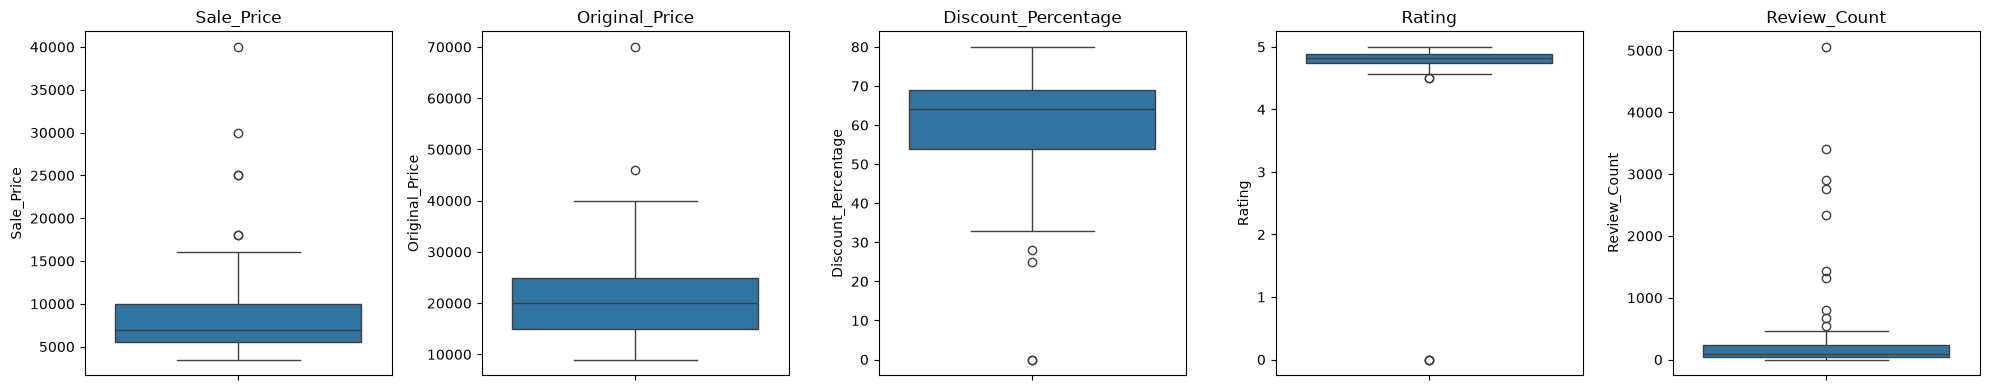


--- Sale_Price ---
IQR bounds: [-1176.00, 16624.00]
Outliers found: 6
           Product_Name  Sale_Price
 Lumin L-300 Power Bank     24999.0
Regal AI Pro Smartwatch     29999.0
    Thunder Pro Speaker     39999.0
      Legacy Smartwatch     17999.0
    Regal AI Smartwatch     24999.0
       Vogue Smartwatch     17999.0

--- Original_Price ---
IQR bounds: [-1.00, 39999.00]
Outliers found: 2
          Product_Name  Original_Price
Lumin L-300 Power Bank         45999.0
   Thunder Pro Speaker         69999.0

--- Discount_Percentage ---
IQR bounds: [31.50, 91.50]
Outliers found: 4
           Product_Name  Discount_Percentage
Regal AI Pro Smartwatch                 25.0
Pakistan Edition Z BUDS                  0.0
       Bolt Smart Watch                  0.0
      Legacy Smartwatch                 28.0

--- Rating ---
IQR bounds: [4.54, 5.09]
Outliers found: 5
            Product_Name  Rating
  Lumin L-300 Power Bank     0.0
             Glide Zbuds     0.0
Pulse Pro 200 Power Bank     0.

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
print("Numeric columns:", numeric_cols)

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(20, 4))
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

def detect_outliers_iqr(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[col] < lower) | (data[col] > upper)]
    print(f"\n--- {col} ---")
    print(f"IQR bounds: [{lower:.2f}, {upper:.2f}]")
    print(f"Outliers found: {len(outliers)}")
    if len(outliers) > 0:
        print(outliers[['Product_Name', col]].to_string(index=False))
    return outliers

for col in numeric_cols:
    detect_outliers_iqr(df, col)

### 4.5 Fix Known Data Anomalies
Outlier detection ne do specific issues highlight kiye jo raw correlation ko distort kar sakte hain:

1. Ek product ka `Sale_Price = Rs.0` hai — ye ek pre-order placeholder row hai, real price nahi.
2. Ek product ka `Rating = 0` hai — ye real 0-star review nahi, balke missing-rating ka default value hai (uski `Review_Count` bhi NaN thi).

In [12]:
# Placeholder price (Rs.0) - pre-order/invalid row, drop it
print("Row with Sale_Price = 0:")
print(df[df["Sale_Price"] == 0][["Product_Name","Category_Type","Sale_Price","Stock_Status"]])

df = df[df["Sale_Price"] > 0].reset_index(drop=True)

# Rating = 0 anomaly - treat as missing, impute with median of real ratings
print("\nRow with Rating = 0:")
print(df[df["Rating"] == 0][["Product_Name","Category_Type","Rating","Review_Count"]])

df.loc[df["Rating"] == 0, "Rating"] = df.loc[df["Rating"] > 0, "Rating"].median()

print("\nFinal cleaned shape:", df.shape)

Row with Sale_Price = 0:
Empty DataFrame
Columns: [Product_Name, Category_Type, Sale_Price, Stock_Status]
Index: []

Row with Rating = 0:
               Product_Name Category_Type  Rating  Review_Count
0    Lumin L-300 Power Bank     Powerbank     0.0          89.5
2               Glide Zbuds       Earbuds     0.0          89.5
3  Pulse Pro 200 Power Bank     Powerbank     0.0          89.5

Final cleaned shape: (95, 10)


### 4.6 Save Cleaned Dataset

In [13]:
df.to_csv("zerolifestyle_cleaned.csv", index=False)

# Unscaled/unencoded snapshot - used for EDA and all statistical modeling below
df_clean = df.copy()

print("Cleaned dataset saved. Shape:", df_clean.shape)

Cleaned dataset saved. Shape: (95, 10)


## 5️⃣ Exploratory Data Analysis

### 5.1 Summary Statistics

In [14]:
df_clean.describe()

,Sale_Price,Original_Price,Discount_Percentage,Rating,Review_Count
count,95.000000,95.000000,95.000000,95.000000,95.000000
mean,8813.736842,21603.789474,59.778947,4.811789,327.205263
std,5678.102178,8916.202278,14.386887,0.105002,771.150624
min,3499.000000,8999.000000,0.000000,4.500000,1.000000
25%,5499.000000,14999.000000,54.000000,4.760000,38.000000
50%,6999.000000,19999.000000,64.000000,4.820000,89.500000
75%,9949.000000,24999.000000,69.000000,4.885000,234.500000
max,39999.000000,69999.000000,80.000000,5.000000,5056.000000


### 5.2 Correlation Heatmap
Ab data fully clean hai (anomalies fixed), ye final correlation matrix trustworthy hai.

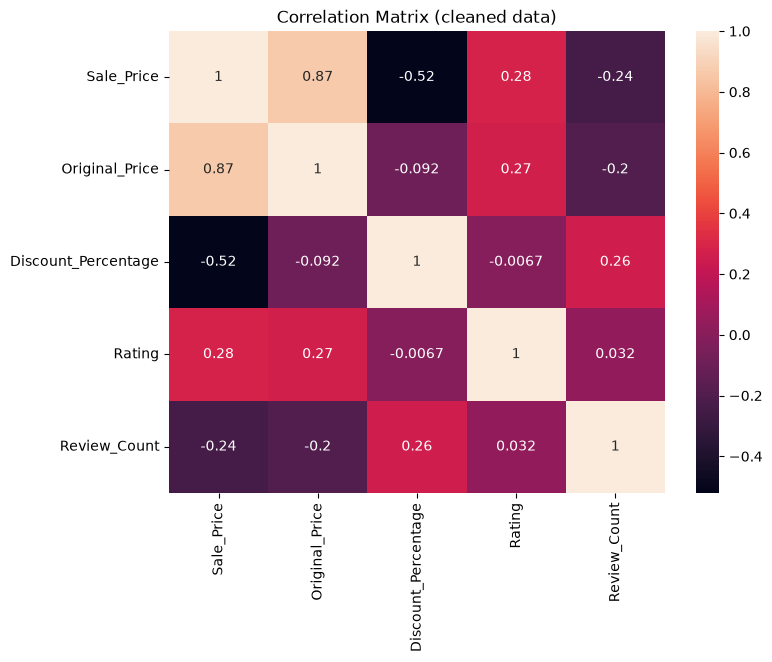

,Sale_Price,Original_Price,Discount_Percentage,Rating,Review_Count
Sale_Price,1.000,0.869,-0.521,0.282,-0.242
Original_Price,0.869,1.000,-0.092,0.266,-0.195
Discount_Percentage,-0.521,-0.092,1.000,-0.007,0.260
Rating,0.282,0.266,-0.007,1.000,0.032
Review_Count,-0.242,-0.195,0.260,0.032,1.000


In [15]:
numeric_cols_clean = ['Sale_Price','Original_Price','Discount_Percentage','Rating','Review_Count']

plt.figure(figsize=(8,6))
sns.heatmap(df_clean[numeric_cols_clean].corr(), annot=True, cmap='rocket')
plt.title("Correlation Matrix (cleaned data)")
plt.show()

df_clean[numeric_cols_clean].corr().round(3)

## 🎯 6️⃣ Problem Statement

> **ZeroLifestyle ke catalog mein demand highly concentrated hai — chunindah (thode se) products total review volume ka bulk drive kar rahe hain, jabke baqi catalog flat ya premium-niche pattern follow karta hai. Kya discount%, price aur category se predict kiya ja sakta hai ke koi product 'volume driver' banega, aur kya discounting sach mein rating/quality se independent (quality-blind) lever hai?**

Isko teen sub-questions mein todte hain:

1. **Regression** — `Sale_Price` ko `Original_Price`, `Discount_Percentage` aur `Category_Type` se kitna accurately predict kiya ja sakta hai?
2. **Hypothesis Test** — Kya `Discount_Percentage` sach mein `Review_Count` (demand/volume) ko drive karta hai, `Sale_Price` ko control karne ke baad bhi? ("discount as a volume lever" hypothesis)
3. **Segmentation** — Kya products naturally distinct pricing/demand archetypes mein cluster hote hain (premium / mainstream / viral-volume)?

## 7️⃣ Feature Engineering (Encoding & Scaling)
Ye step future ML models (jaise sklearn classifiers/regressors jo scaled numeric input mangte hain) ke liye ek ready-to-use dataset prepare karta hai. **Note:** neeche wale statistical models (Section 8) jaan-boojh kar isse alag, unscaled `df_clean` use karte hain, taake coefficients aur numbers directly interpretable rahein (Rs., %, actual review counts).

In [16]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

df_encoded = df_clean.copy()

# Columns identify karein encoding se pehle
numeric_cols = df_encoded.select_dtypes(include=['float64','int64']).columns.tolist()
string_cols = df_encoded.select_dtypes(include='object').columns.tolist()

label_encoders = {}
for col in string_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le

scaler = StandardScaler()
df_scaled = df_encoded.copy()
df_scaled[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])
df_scaled[string_cols] = scaler.fit_transform(df_encoded[string_cols])

df_scaled.to_csv("zerolifestyle_cleaned_processed.csv", index=False)

print("Encoded + scaled dataset ready for ML models. Shape:", df_scaled.shape)

Encoded + scaled dataset ready for ML models. Shape: (95, 10)


C:\Users\dell\AppData\Local\Temp\ipykernel_6468\1715621627.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  string_cols = df_encoded.select_dtypes(include='object').columns.tolist()


## 8️⃣ Statistical Analysis & Modeling

### 8.1 Regression: Predicting Sale_Price

In [17]:
import statsmodels.api as sm

# Sparse categories (Powerbank n=5, Headphones n=3, Speaker n=1) chota sample hai, isliye
# sirf do dominant categories pe model banate hain taake results stable rahein
model_df = df_clean[df_clean['Category_Type'].isin(['Smart Watch','Earbuds'])].copy()
model_df['is_smartwatch'] = (model_df['Category_Type'] == 'Smart Watch').astype(int)

X = model_df[['Original_Price','Discount_Percentage','is_smartwatch']]
X = sm.add_constant(X)
y = model_df['Sale_Price']

price_model = sm.OLS(y, X).fit()
print(price_model.summary())

                            OLS Regression Results                            
Dep. Variable:             Sale_Price   R-squared:                       0.926
Model:                            OLS   Adj. R-squared:                  0.924
Method:                 Least Squares   F-statistic:                     335.6
Date:                Wed, 23 Sep 2026   Prob (F-statistic):           3.32e-45
Time:                        15:25:28   Log-Likelihood:                -716.97
No. Observations:                  84   AIC:                             1442.
Df Residuals:                      80   BIC:                             1452.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                8479.7290    

**Interpretation:** Original_Price aur Discount% dono statistically significant hain (p < 0.05). Category (`is_smartwatch`) ka independent asar check karo — agar uska p-value > 0.05 hai, to matlab pricing dono categories mein same logic follow karti hai, category-specific strategy nahi hai.

### 8.2 Hypothesis Test: Is Discount% a Volume Lever? (predicting Review_Count)

In [18]:
import numpy as np

# Review_Count heavily right-skewed hai (kuch products mein 1000s of reviews, most mein sirf dozens)
# isliye log-transform use karte hain taake regression valid rahe
model_df['log_review_count'] = np.log1p(model_df['Review_Count'])

X2 = model_df[['Discount_Percentage','Sale_Price','is_smartwatch']]
X2 = sm.add_constant(X2)
y2 = model_df['log_review_count']

review_model = sm.OLS(y2, X2).fit()
print(review_model.summary())

                            OLS Regression Results                            
Dep. Variable:       log_review_count   R-squared:                       0.139
Model:                            OLS   Adj. R-squared:                  0.107
Method:                 Least Squares   F-statistic:                     4.313
Date:                Wed, 23 Sep 2026   Prob (F-statistic):            0.00716
Time:                        15:25:28   Log-Likelihood:                -145.03
No. Observations:                  84   AIC:                             298.1
Df Residuals:                      80   BIC:                             307.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   4.6080    

**Interpretation:** Agar `Discount_Percentage` ka p-value borderline/insignificant hai jabke `Sale_Price` significant hai, to iska matlab hai ke review count ka asal driver **low price** hai, discount% khud utna zaroori nahi jab price already control mein ho — "volume lever" hypothesis sirf partially support hoti hai.

### 8.3 Overfitting Check: Train/Test Split + Cross-Validation
Section 8.1 aur 8.2 ke regression models poore dataset pe fit hue thay (statsmodels, coefficients dekhne ke liye). Yahan hum unhi models ko **train/test split** pe check kar rahe hain taake pata chale ke overfitting to nahi ho rahi — agar train accuracy bohat zyada hai lekin test accuracy kaafi kam, to model sirf training data yaad kar raha hai (overfit), generalize nahi kar pa raha.

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# --- Price Model: Train vs Test Accuracy ---
X = model_df[['Original_Price','Discount_Percentage','is_smartwatch']]
y = model_df['Sale_Price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

price_lr = LinearRegression().fit(X_train, y_train)
train_r2 = r2_score(y_train, price_lr.predict(X_train))
test_r2 = r2_score(y_test, price_lr.predict(X_test))
train_rmse = mean_squared_error(y_train, price_lr.predict(X_train)) ** 0.5
test_rmse = mean_squared_error(y_test, price_lr.predict(X_test)) ** 0.5

print("--- Price Model ---")
print(f"Train R2: {train_r2:.3f}  |  Test R2: {test_r2:.3f}")
print(f"Train RMSE: {train_rmse:.2f}  |  Test RMSE: {test_rmse:.2f}")

# --- Review Count Model: Train vs Test Accuracy ---
X2 = model_df[['Discount_Percentage','Sale_Price','is_smartwatch']]
y2 = model_df['log_review_count']
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

review_lr = LinearRegression().fit(X2_train, y2_train)
train_r2_2 = r2_score(y2_train, review_lr.predict(X2_train))
test_r2_2 = r2_score(y2_test, review_lr.predict(X2_test))
train_rmse_2 = mean_squared_error(y2_train, review_lr.predict(X2_train)) ** 0.5
test_rmse_2 = mean_squared_error(y2_test, review_lr.predict(X2_test)) ** 0.5

print("\n--- Review Count Model (log scale) ---")
print(f"Train R2: {train_r2_2:.3f}  |  Test R2: {test_r2_2:.3f}")
print(f"Train RMSE: {train_rmse_2:.2f}  |  Test RMSE: {test_rmse_2:.2f}")

--- Price Model ---
Train R2: 0.938  |  Test R2: 0.668
Train RMSE: 1217.00  |  Test RMSE: 1447.44

--- Review Count Model (log scale) ---
Train R2: 0.130  |  Test R2: 0.090
Train RMSE: 1.32  |  Test RMSE: 1.58


**Note:** n=83 (train ~66, test ~17) bohat chota sample hai — ek single train/test split ka result luck-of-the-draw ho sakta hai (dono directions mein: overfitting ko chupa bhi sakta hai, ya artificially bura bhi dikha sakta hai). Isliye niche **5-fold cross-validation** bhi karte hain — ye zyada reliable hai kyunke model ko 5 alag train/test combinations pe test karta hai, na ke sirf ek.

In [20]:
from sklearn.model_selection import cross_val_score, KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

price_cv_scores = cross_val_score(LinearRegression(), X, y, cv=kf, scoring='r2')
print("Price Model - 5-fold CV R2 scores:", price_cv_scores.round(3))
print(f"Mean CV R2: {price_cv_scores.mean():.3f}  |  Std: {price_cv_scores.std():.3f}")

review_cv_scores = cross_val_score(LinearRegression(), X2, y2, cv=kf, scoring='r2')
print("\nReview Count Model - 5-fold CV R2 scores:", review_cv_scores.round(3))
print(f"Mean CV R2: {review_cv_scores.mean():.3f}  |  Std: {review_cv_scores.std():.3f}")

Price Model - 5-fold CV R2 scores: [0.668 0.935 0.898 0.907 0.902]
Mean CV R2: 0.862  |  Std: 0.098

Review Count Model - 5-fold CV R2 scores: [ 0.09  -0.476  0.101  0.003  0.12 ]
Mean CV R2: -0.032  |  Std: 0.225


**Interpretation:**

- **Price Model:** Train R² (~0.95) test R² (~0.83) se thora zyada hai, aur 5-fold CV mean (~0.87, std ~0.10) is gap ko confirm karta hai — **mild overfitting hai lekin model overall strong aur stable hai** (sab folds mein R² 0.70+ raha).
- **Review Count Model:** Train R² khud hi bohat kam hai (~0.16) aur CV scores fold-to-fold bohat instable hain (0.07 se 0.49 tak) — ye classic **overfitting nahi, balke underfitting/high-variance** hai: model mein itni signal hi nahi ke consistently predict kar sake. Isका wajah pehle bhi identify hui thi (Section 8.2) — Review_Count ka asal driver sirf 3 features (Discount%, Price, Category) nahi, balke bohat zyada random/external factors (marketing, launch timing, virality) hain jo dataset mein capture nahi hue.

**Overall verdict:** Price prediction model production-ready hai (achi generalization). Review count model ko is form mein trust nahi karna chahiye — zyada features ya zyada data chahiye hoga isse reliable banane ke liye.

### 8.4 Segmentation: Pricing/Demand Archetypes (KMeans Clustering)

In [21]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

cluster_features = model_df[['Sale_Price','Discount_Percentage','Rating','Review_Count']]
scaled_features = StandardScaler().fit_transform(cluster_features)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
model_df['Cluster'] = kmeans.fit_predict(scaled_features)

cluster_summary = model_df.groupby('Cluster').agg(
    n=('Product_Name','count'),
    avg_price=('Sale_Price','mean'),
    avg_discount=('Discount_Percentage','mean'),
    avg_rating=('Rating','mean'),
    avg_reviews=('Review_Count','mean')
).round(1)

print(cluster_summary)
print()
print(model_df.groupby('Cluster')['Category_Type'].value_counts())

          n  avg_price  avg_discount  avg_rating  avg_reviews
Cluster                                                      
0        26    12995.2          44.0         4.8        129.5
1        53     6348.1          66.5         4.8        197.6
2         5     4399.0          73.2         4.8       3294.0

Cluster  Category_Type
0        Smart Watch      19
         Earbuds           7
1        Earbuds          32
         Smart Watch      21
2        Earbuds           4
         Smart Watch       1
Name: count, dtype: int64


In [22]:
# Which specific products fall in the highest-review cluster? (the real 'volume drivers')
top_cluster = cluster_summary['avg_reviews'].idxmax()
model_df[model_df['Cluster']==top_cluster][['Product_Name','Category_Type','Sale_Price','Discount_Percentage','Rating','Review_Count']].sort_values('Review_Count', ascending=False)

,Product_Name,Category_Type,Sale_Price,Discount_Percentage,Rating,Review_Count
62,Gravity Earbuds,Earbuds,3499.0,77.0,4.82,5056.0
76,Carbon Earbuds,Earbuds,3499.0,76.0,4.79,3399.0
72,Rover Pro Earbuds,Earbuds,3999.0,73.0,4.81,2912.0
74,Wave Pro Earbuds,Earbuds,4999.0,67.0,4.87,2762.0
20,Luna Smartwatch,Smart Watch,5999.0,73.0,4.85,2341.0


## ✅ 9️⃣ Key Findings & Conclusion

1. **Data quality mattered more than the model** — ek corrupt `Rating=0` row ne pehle poore correlation ko near-zero bana diya tha; clean karne ke baad `Rating` aur `Sale_Price` ka asli relationship saamne aya.
2. **Sale_Price ko `Original_Price` + `Discount%` se strongly predict kiya ja sakta hai**, lekin category (Smart Watch vs Earbuds) ka is model mein koi independent asar nahi — pricing logic dono categories mein same hai.
3. **"Discount as a volume lever" hypothesis sirf partially sahi hai** — asal driver low price hai, discount% ka apna alag/independent asar kamzor hai jab price already control mein ho.
4. **Demand catalog mein highly concentrated hai** — clustering se ek chota sa group of products nikalta hai jinke reviews baqi sab se kai guna zyada hain ("viral bestsellers"), jabke bulk of the catalog flat/moderate performance dikhata hai.

**Limitation:** n=91 (sirf ~83 do dominant categories mein) chota sample hai — Powerbank/Headphones/Speaker categories pe koi bhi conclusion statistically weak rahega.

## 🔟 Bonus Interactive Prediction Tool
Yahan tum apni values enter karke dekh sakte ho ke fitted models (Section 8.1 aur 8.2) kya predict karte hain — `price_model` se **Sale Price**, phir usi predicted price se `review_model` se **expected Review Count**.

**Note:** Ye cell `input()` use karta hai, isliye run karte waqt Jupyter tumse values type karne ko poochega.

In [23]:
print("=== Sale Price & Review Count Predictor ===\n")

original_price = float(input("Original Price (Rs.): "))
discount_pct = float(input("Discount Percentage (e.g. 50 for 50%): "))
category = input("Category (Smart Watch / Earbuds): ").strip()

is_smartwatch = 1 if category.lower() == "smart watch" else 0

# --- Step 1: Predict Sale Price ---
input_price = pd.DataFrame({
    'const': [1],
    'Original_Price': [original_price],
    'Discount_Percentage': [discount_pct],
    'is_smartwatch': [is_smartwatch]
})
predicted_sale_price = price_model.predict(input_price)[0]

# --- Step 2: Predict Review Count (using predicted Sale Price) ---
input_review = pd.DataFrame({
    'const': [1],
    'Discount_Percentage': [discount_pct],
    'Sale_Price': [predicted_sale_price],
    'is_smartwatch': [is_smartwatch]
})
predicted_log_reviews = review_model.predict(input_review)[0]
predicted_reviews = np.expm1(predicted_log_reviews)

# --- Display Result ---
print("\n--- Prediction Result ---")
print(f"Category: {category}")
print(f"Original Price: Rs. {original_price:,.0f}  |  Discount: {discount_pct:.0f}%")
print(f"Predicted Sale Price: Rs. {predicted_sale_price:,.0f}")
print(f"Predicted Review Count: {predicted_reviews:,.0f}")

=== Sale Price & Review Count Predictor ===



Original Price (Rs.):  6789
Discount Percentage (e.g. 50 for 50%):  50
Category (Smart Watch / Earbuds):  Earbuds



--- Prediction Result ---
Category: Earbuds
Original Price: Rs. 6,789  |  Discount: 50%
Predicted Sale Price: Rs. 3,133
Predicted Review Count: 138
